In [1]:
import os
for root,dirs,files in os.walk('/workspace'):
 if root.count(os.sep)>3: dirs[:]=[]; continue
 print(root,[(f,round(os.path.getsize(os.path.join(root,f))/1024,1)) for f in files[:30]])

/workspace [('corny7_README.md', 9.4), ('justin_plot_drop2.png', 58.0), ('corny7_drops.csv', 4.6), ('.kernel_llm_logs_1.txt', 0.0), ('justin_numarical_work.py', 2.4), ('justin_plot_drop1.png', 56.8), ('justin_intent.md', 1.3), ('justin_derivation_transcribed.md', 1.1), ('justin_work_derivation.pdf', 652.9), ('corny7_waveforms_50kHz.csv', 3414.8), ('justin_implimatation_or_work.py', 1.7), ('PROMPT.md', 4.9)]
/workspace/memory [('a74889a5-2a13-4aac-abe1-fcce1e4905c4_memory_heron_c0_20260929T213230730263.jsonl', 20.2)]
/workspace/.config []
/workspace/.config/a74889a5-2a13-4aac-abe1-fcce1e4905c4 []
/workspace/.prompts [('MEMORY.md', 0.4), ('USER.md', 0.7), ('BOOTSTRAP.md', 5.5)]


(100000, 6)  drop_number  time_ms  ch2_g  ch3_g  ch4_g  ch5_g
           1     0.00  0.849  4.440  6.818  7.958
           1     0.02  0.636  4.227  7.345  7.804
           1     0.04  0.223  3.653  7.320  8.013
           1     0.06 -0.398  3.386  7.430  8.055
           1     0.08 -0.933  3.045  7.315  8.426
[5000]


script exact stdout: -9.459488563303363 jouls per kilogam
 stderr:  return 0
-11.278084965922268 jouls per kilogam
plot files: []


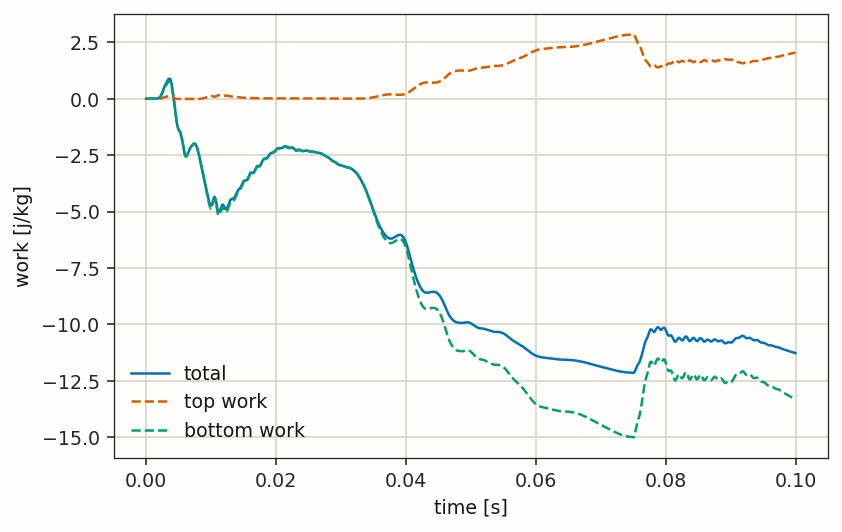

In [2]:
import pandas as pd,numpy as np,scipy as sp, scipy.signal as sig, scipy.integrate as integ, pathlib, subprocess, sys, os
os.chdir('/workspace'); out=pathlib.Path('work_review');out.mkdir(exist_ok=True)
d=pd.read_csv('corny7_drops.csv');w=pd.read_csv('corny7_waveforms_50kHz.csv'); print(w.shape,w.head().to_string(index=False));print(w.groupby('drop_number').size().unique());
# run exact script no edits
p=subprocess.run([sys.executable,'justin_implimatation_or_work.py'],cwd='/workspace',env={**os.environ,'MPLBACKEND':'Agg'},capture_output=True,text=True);print('script exact stdout:',p.stdout,'stderr:',p.stderr,'return',p.returncode)
# same script with only selector switched, in memory, so original remains untouched
src=pathlib.Path('justin_implimatation_or_work.py').read_text();exec(compile(src.replace('data[:, 0] == 2','data[:, 0] == 1'),'<original-except-drop-selector>','exec'),{'__name__':'__main__'})
print('plot files:',[(x.name,x.stat().st_size) for x in out.iterdir()])

In [3]:
from e14c.web import web_search
queries=['SAE J211/1 instrumentation impact tests channel frequency class CFC 180 standard filtering', 'ASTM D1596 dynamic shock cushioning characteristics packaging materials drop test energy', 'piezoelectric accelerometer zero shift shock acceleration integration velocity displacement drift paper', 'accelerometer double integration shock zero shift displacement baseline correction literature']
results=await __import__('asyncio').gather(*(web_search(q,num_results=5) for q in queries))
for q,r in zip(queries,results): print('\nQUERY',q,'\n',str(r)[:5300])


QUERY SAE J211/1 instrumentation impact tests channel frequency class CFC 180 standard filtering 
 [{'title': 'J211/1_202208: Instrumentation for Impact Test Part 1 - Electronic Instrumentation - Recommended Practice', 'url': 'https://saemobilus.sae.org/standards/j2111_202208-instrumentation-impact-test-part-1-electronic-instrumentation', 'publishedDate': '2022-08-19T00:00:00.000Z', 'full_text': 'J211/1_202208: Instrumentation for Impact Test Part 1 - Electronic Instrumentation - Recommended Practice\n\n## 8/19/2022 \n\nFeatures\n: equalizer \n\nData Sets\n\n compare_arrows \n\nRedlined\n\nIssuing Committee\n: Safety Test Instrumentation Standards Committee\n\n Scope \n\nContent\n: This SAE Recommended Practice outlines a series of performance recommendations, which concern the whole data channel. These recommendations are not subject to any variation and all of them shall be adhered to by any agency conducting tests to this practice. However, the method of demonstrating compliance wi

In [4]:
for k in [1,2,3,10,20]:
 z=w[w.drop_number==k];print('drop',k)
 for nm,mask in [('pre',z.time_ms<1.5),('tail',z.time_ms>=70),('quiet', (z.time_ms>=12)&(z.time_ms<30)),('impact',(z.time_ms>=2)&(z.time_ms<8))]:
  q=z.loc[mask,['ch2_g','ch3_g','ch4_g','ch5_g']]; print(nm,'median',q.median().round(2).to_dict(),'max',q.max().round(1).to_dict(),'min',q.min().round(1).to_dict())
print('session tail ranges'); print(w[w.time_ms>=70].groupby('drop_number')[['ch2_g','ch3_g','ch4_g','ch5_g']].median().agg(['min','median','max']).round(3))
print('session pre ranges'); print(w[w.time_ms<1.5].groupby('drop_number')[['ch2_g','ch3_g','ch4_g','ch5_g']].median().agg(['min','median','max']).round(3))

drop 1
pre median {'ch2_g': -1.28, 'ch3_g': 0.79, 'ch4_g': 15.12, 'ch5_g': 17.6} max {'ch2_g': 1.2, 'ch3_g': 4.4, 'ch4_g': 37.3, 'ch5_g': 56.6} min {'ch2_g': -7.6, 'ch3_g': -7.0, 'ch4_g': 6.8, 'ch5_g': 7.8}
tail median {'ch2_g': 1.56, 'ch3_g': 4.51, 'ch4_g': 3.8, 'ch5_g': -2.3} max {'ch2_g': 28.3, 'ch3_g': 32.7, 'ch4_g': 17.3, 'ch5_g': 40.7} min {'ch2_g': -55.3, 'ch3_g': -19.8, 'ch4_g': -5.6, 'ch5_g': -27.1}
quiet median {'ch2_g': -1.46, 'ch3_g': 16.15, 'ch4_g': 5.87, 'ch5_g': -1.88} max {'ch2_g': 11.8, 'ch3_g': 50.3, 'ch4_g': 11.2, 'ch5_g': 1.5} min {'ch2_g': -17.9, 'ch3_g': -0.9, 'ch4_g': 0.5, 'ch5_g': -5.0}
impact median {'ch2_g': 0.48, 'ch3_g': -10.68, 'ch4_g': 42.41, 'ch5_g': 12.34} max {'ch2_g': 46.6, 'ch3_g': 17.4, 'ch4_g': 210.2, 'ch5_g': 279.0} min {'ch2_g': -41.8, 'ch3_g': -104.8, 'ch4_g': 1.0, 'ch5_g': -3.0}
drop 2
pre median {'ch2_g': -1.38, 'ch3_g': 0.2, 'ch4_g': 12.99, 'ch5_g': 18.41} max {'ch2_g': -0.4, 'ch3_g': 3.7, 'ch4_g': 35.9, 'ch5_g': 56.0} min {'ch2_g': -5.8, 'ch3

In [5]:
G=9.80665;fs=50000;sos=sig.butter(2,300,fs=fs,output='sos')
def integ_metrics(k,start=0,end=12,baseline='tail',fc=300,grav=0,axis='ch4_g',vrel0=0, endv=None):
 z=w[w.drop_number==k]; t=z.time_ms.to_numpy()*1e-3; sel=(t>=start/1000)&(t<=end/1000); 
 a=[]
 for ch in [axis,'ch5_g']:
  x=z[ch].to_numpy(); b=np.median(x[(t>=.070)&(t<.1)]) if baseline=='tail' else np.median(x[t<.0015]) if baseline=='pre' else 0.
  x=(x-b)*G
  x=sig.sosfiltfilt(sig.butter(2,fc,fs=fs,output='sos'),x) if fc else x
  a.append(x[sel])
 ts=t[sel];at,ab=a; ar=at-ab
 vr=integ.cumulative_trapezoid(ar,ts,initial=0)+vrel0
 if endv is not None: vr+=np.linspace(0,endv-vr[-1],len(vr)) # linear drift correction; equivalent constant acceleration removal
 L=integ.cumulative_trapezoid(vr,ts,initial=0)
 f=at+grav*G
 W=integ.trapezoid(f*vr,ts)
 return dict(W=W,vend=vr[-1],Lend=L[-1],Lmin=L.min(),Lmax=L.max(),fmin=f.min(),fmax=f.max(),vt=integ.trapezoid(at,ts),vb=integ.trapezoid(ab,ts),t=ts,L=L,f=f,vr=vr,at=at,ab=ab)
for k in [1,2,3,10,20]:
 print('drop',k)
 for end in [7,10,12,15,30,100]:
  r=integ_metrics(k,end=end,fc=300);print(end, {q:round(r[q],3) for q in ['W','vend','Lend','Lmin','Lmax','vt','vb']})


drop 1
7 {'W': np.float64(-4.489), 'vend': np.float64(-1.23), 'Lend': np.float64(-0.006), 'Lmin': np.float64(-0.006), 'Lmax': np.float64(0.0), 'vt': np.float64(4.365), 'vb': np.float64(5.595)}
10 {'W': np.float64(-4.651), 'vend': np.float64(-1.153), 'Lend': np.float64(-0.01), 'Lmin': np.float64(-0.01), 'Lmax': np.float64(0.0), 'vt': np.float64(4.499), 'vb': np.float64(5.653)}
12 {'W': np.float64(-4.804), 'vend': np.float64(-1.006), 'Lend': np.float64(-0.012), 'Lmin': np.float64(-0.012), 'Lmax': np.float64(0.0), 'vt': np.float64(4.64), 'vb': np.float64(5.646)}
15 {'W': np.float64(-4.85), 'vend': np.float64(-0.952), 'Lend': np.float64(-0.015), 'Lmin': np.float64(-0.015), 'Lmax': np.float64(0.0), 'vt': np.float64(4.687), 'vb': np.float64(5.639)}
30 {'W': np.float64(-5.112), 'vend': np.float64(-0.749), 'Lend': np.float64(-0.027), 'Lmin': np.float64(-0.027), 'Lmax': np.float64(0.0), 'vt': np.float64(4.998), 'vb': np.float64(5.747)}
100 {'W': np.float64(-4.158), 'vend': np.float64(-1.571), '

In [6]:
for k in [1,2,3]:
 print('drop',k)
 for axis in ['ch2_g','ch3_g','ch4_g']:
  for baseline in ['none','tail','pre']:
   rr=integ_metrics(k,end=99.98,axis=axis,baseline=baseline,fc=None,grav=1); print(axis,baseline, 'W',round(rr['W'],2),'Lmm',round(rr['Lend']*1000,1),'vr',round(rr['vend'],2),'Wtop',round(integ.trapezoid(rr['f']*integ.cumulative_trapezoid(rr['at'],rr['t'],initial=0),rr['t']),2))
 print('3-12ms CH4 tail',[(ed,round(integ_metrics(k,end=ed)['W'],2)) for ed in [8,12,15]])

drop 1
ch2_g none W -11.25 Lmm -341.3 vr -1.96 Wtop 2.06
ch2_g tail W -6.95 Lmm -530.2 vr -5.74 Wtop 0.21
ch2_g pre W 14.68 Lmm 584.3 vr 16.55 Wtop 5.34
ch3_g none W -15.92 Lmm -193.7 vr 1.2 Wtop 13.21
ch3_g tail W -10.55 Lmm -527.5 vr -5.48 Wtop 0.26
ch3_g pre W 23.53 Lmm 630.1 vr 17.68 Wtop 9.52
ch4_g none W 3.18 Lmm 182.9 vr 4.42 Wtop 37.08
ch4_g tail W -5.33 Lmm -115.8 vr -1.55 Wtop 12.88
ch4_g pre W -36.75 Lmm 304.6 vr 6.86 Wtop 22.98
3-12ms CH4 tail [(8, np.float64(-4.49)), (12, np.float64(-4.8)), (15, np.float64(-4.85))]
drop 2
ch2_g none W -9.43 Lmm -416.1 vr -3.62 Wtop 0.93
ch2_g tail W -7.26 Lmm -483.5 vr -4.97 Wtop 0.28
ch2_g pre W 12.28 Lmm 553.9 vr 15.79 Wtop 3.64
ch3_g none W -17.74 Lmm -266.9 vr -0.38 Wtop 10.35
ch3_g tail W -7.32 Lmm -522.5 vr -5.49 Wtop -0.06
ch3_g pre W 25.37 Lmm 625.9 vr 17.48 Wtop 9.49
ch4_g none W -0.44 Lmm 126.0 vr 2.82 Wtop 32.37
ch4_g tail W -4.93 Lmm -4.8 vr 0.21 Wtop 19.28
ch4_g pre W -41.03 Lmm 391.8 vr 8.14 Wtop 14.55
3-12ms CH4 tail [(8, np

In [7]:
for k in [1,2,3,10]:
 print('drop',k)
 for en in [8,15,30,99.98]:
  print(en,[(axis,ba,round(integ_metrics(k,end=en,axis=axis,baseline=ba,fc=None,grav=1)['W'],2)) for axis in ['ch2_g','ch4_g'] for ba in ['none','tail']])
# numeric test run script as written, inspect print
p2=subprocess.run([sys.executable,'justin_numarical_work.py'],cwd='/workspace',env={**os.environ,'MPLBACKEND':'Agg'},capture_output=True,text=True);print(p2.returncode,p2.stdout,p2.stderr[:500])

drop 1
8 [('ch2_g', 'none', np.float64(-2.32)), ('ch2_g', 'tail', np.float64(-1.93)), ('ch4_g', 'none', np.float64(-3.96)), ('ch4_g', 'tail', np.float64(-4.61))]
15 [('ch2_g', 'none', np.float64(-3.65)), ('ch2_g', 'tail', np.float64(-2.74)), ('ch4_g', 'none', np.float64(-4.22)), ('ch4_g', 'tail', np.float64(-5.02))]
30 [('ch2_g', 'none', np.float64(-2.94)), ('ch2_g', 'tail', np.float64(-0.6)), ('ch4_g', 'none', np.float64(-3.73)), ('ch4_g', 'tail', np.float64(-5.39))]
99.98 [('ch2_g', 'none', np.float64(-11.25)), ('ch2_g', 'tail', np.float64(-6.95)), ('ch4_g', 'none', np.float64(3.18)), ('ch4_g', 'tail', np.float64(-5.33))]
drop 2
8 [('ch2_g', 'none', np.float64(-2.53)), ('ch2_g', 'tail', np.float64(-2.37)), ('ch4_g', 'none', np.float64(-4.33)), ('ch4_g', 'tail', np.float64(-4.63))]
15 [('ch2_g', 'none', np.float64(-3.13)), ('ch2_g', 'tail', np.float64(-2.74)), ('ch4_g', 'none', np.float64(-4.53)), ('ch4_g', 'tail', np.float64(-4.9))]
30 [('ch2_g', 'none', np.float64(-0.86)), ('ch2_g',

0 3.913765976614389e-06 3.839256520011986e-05
 


In [8]:
import sympy as sy
x=sy.symbols('x');a=-x**5+9*x**4-15*x**3-6*x**2+7*x+1
P=sy.integrate(a,x);Wtrue=sy.Rational(981,100)*P+a*P # no derivative? analytical W= g*P + 1/2*P**2 if v=P-P(t0)
t0=-.66543; V=P-P.subs(x,t0);W=sy.Rational(981,100)*sy.integrate(V,x)+V**2/2; 
true=sy.sympify('0.81147276783173 + 5.405*x**2 + 14.945*x**3 - 0.78*x**4 - 18.1074999999999*x**5 - 6.382*x**6 + 13.3997619047619*x**7 + 2.84791666666666*x**8 - 6.41666666666666*x**9 + 2.245*x**10 - 0.3*x**11 + 0.0138888888888888*x**12');
print('poly true derivative discrepancy against (g+a)*V at:',[(q,float((sy.diff(true,x)-(sy.Rational(981,100)+a)*V).subs(x,q))) for q in [t0,0,1,2.49]])
print('true at start',float(true.subs(x,t0)),'V at start',float(V.subs(x,t0)),'expected relative W true start',0)
# numeric derivative discrepancy with polynomial integration result
print('offset in assumed V from polynomial:',float(P.subs(x,t0)),'true derivative at start',float(sy.diff(true,x).subs(x,t0)))

poly true derivative discrepancy against (g+a)*V at: [(-0.66543, 4.797947684011315), (0, 5.287003776433953), (1, 2.3524965924747776), (2.49, 4.752990701053022)]
true at start -0.0020623687199772534 V at start 5.551115123125783e-17 expected relative W true start 0
offset in assumed V from polynomial: 0.4890845306599401 true derivative at start 4.797947684011316


In [9]:
for q,r in zip(queries,results):
 print('\n',q)
 for z in r[:5]:print(z.get('title','')[:120],z.get('url','')[:220])


 SAE J211/1 instrumentation impact tests channel frequency class CFC 180 standard filtering
J211/1_202208: Instrumentation for Impact Test Part 1 - Electronic Instrumentation - Recommended Practice https://saemobilus.sae.org/standards/j2111_202208-instrumentation-impact-test-part-1-electronic-instrumentation
(R) INSTRUMENTATION FOR IMPACT TEST—PART 1—ELECTRONIC INSTRUMENTATION https://law.resource.org/pub/us/cfr/ibr/005/sae.j211-1.1995.html
CFC Filters - NI https://www.ni.com/docs/en-US/bundle/diadem/page/crash/misc_cfc.html
Instrumentation for Impact Test - Part 1 - Electronic Instrumentation https://www.normsplash.com/Samples/SAE/127987837/SAE-J-211-1-2014-en.pdf
SAE J211-1-2022.pdf PDF download free-seekstandard.com https://seekstandard.com/s/51/b083ccf327/

 ASTM D1596 dynamic shock cushioning characteristics packaging materials drop test energy
D1596 Standard Test Method for  Dynamic Shock Cushioning Characteristics of Packaging Material https://store.astm.org/d1596-14r23.html
D1

In [10]:
for k in [3,10,20]:
 r=integ_metrics(k,end=40,fc=300,grav=1)
 print(k,'v sign changes ms',np.round(r['t'][np.where(np.diff(np.sign(r['vr'])) != 0)[0]]*1000,2)[:20], 'min L',r['Lmin']*1000,'last L',r['Lend']*1000,'last v',r['vend']);
 for ed in [10,15,20,25,30,35,40]:
  rr=integ_metrics(k,end=ed,grav=1);print(ed,round(rr['W'],2),round(rr['Lend']*1000,1),round(rr['vend'],2),end='; ')
 print()

3 v sign changes ms [ 0.  31.4] min L -13.529324572334252 last L -10.985390007253612 last v 0.6032300755242067
10 -4.51 -7.7 -0.67; 15 -4.6 -10.2 -0.45; 20 -4.69 -11.8 -0.24; 25 -4.71 -12.8 -0.16; 30 -4.72 -13.5 -0.07; 35 -4.69 -13.1 0.25; 40 -4.51 -11.0 0.6; 
10 v sign changes ms [ 0.  24.5] min L -11.419457075611044 last L -7.053073335021128 last v 0.7263136020646825
10 -4.53 -7.7 -0.63; 15 -4.63 -10.0 -0.38; 20 -4.7 -11.2 -0.12; 25 -4.71 -11.4 0.01; 30 -4.7 -11.0 0.14; 35 -4.62 -9.7 0.39; 40 -4.41 -7.1 0.73; 
20 v sign changes ms [ 0.   25.96] min L -11.924422217752612 last L -8.135500450176455 last v 0.6939997133635412
10 -4.56 -7.7 -0.65; 15 -4.67 -10.2 -0.42; 20 -4.75 -11.5 -0.14; 25 -4.76 -11.9 -0.02; 30 -4.76 -11.8 0.1; 35 -4.69 -10.6 0.36; 40 -4.49 -8.1 0.69; 


In [11]:
# quantify potential boundary correction effect
for k in [3,10,20]:
 a=integ_metrics(k,end=30,grav=1);b=integ_metrics(k,end=30,grav=1,endv=0)
 print(k,'W uncorrected',a['W'],'end-clamped',b['W'],'delta',b['W']-a['W'])
# verify quadrature second order on physical interval and exact antiderivative consistency
T=np.linspace(0,.015,751);a_fun=lambda t: 5+200*t+300*t*t; b_fun=lambda t: 1+30*t
A=lambda t: 5*t+100*t*t+100*t**3;B=lambda t:t+15*t*t
# F g+a and vrel=A-B; exact via polynomial integration
poly_a=np.polynomial.Polynomial([5,200,300]);poly_b=np.polynomial.Polynomial([1,30]);pa=poly_a.integ();pb=poly_b.integ();ex=((poly_a+G)* (pa-pb)).integ()(.015)
for N in [16,31,61,121,751]:
 t=np.linspace(0,.015,N);top=a_fun(t);bot=b_fun(t)
 vr=integ.cumulative_trapezoid(top-bot,t,initial=0)
 est=integ.trapezoid((G+top)*vr,t)
 print('N',N,'quadrature estimate',est,'error',est-ex)
print('exact',ex)

3 W uncorrected -4.72378537573059 end-clamped -4.652793897079818 delta 0.07099147865077171
10 W uncorrected -4.695950608462699 end-clamped -4.853752003284607 delta -0.15780139482190858
20 W uncorrected -4.758601018668705 end-clamped -4.868059325973513 delta -0.10945830730480743
N 16 quadrature estimate 0.009241329088906252 error 6.400000625003677e-06
N 31 quadrature estimate 0.009236529087962889 error 1.5999996816409845e-06
N 61 quadrature estimate 0.009235329088171996 error 3.999998907482094e-07
N 121 quadrature estimate 0.00923502908825208 error 9.99999708317656e-08
N 751 quadrature estimate 0.009234931648280492 error 2.55999924383965e-09
exact 0.009234929088281248


In [12]:
# Reusable analysis script is assembled as a standalone file and then executed in a fresh Python process.
script=r'''#!/usr/bin/env python3
"""Impact-work *proxy*, not a calibrated dissipation measurement. Inputs in /workspace."""
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.signal import butter, sosfiltfilt
from scipy.integrate import cumulative_trapezoid, trapezoid
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
G=9.80665; FS=50000
DATA=Path('/workspace')
OUT=DATA/'work_review'; OUT.mkdir(exist_ok=True)
w=pd.read_csv(DATA/'corny7_waveforms_50kHz.csv')
drops=pd.read_csv(DATA/'corny7_drops.csv').set_index('drop_number')
series={k:z.reset_index(drop=True) for k,z in w.groupby('drop_number')}
def calc(k,end_ms=15,fc=300,tail=(70,100),v0=0,gravity=True,clamp_end=False):
    z=series[k]; t=z.time_ms.to_numpy()/1000
    sl=(t>=0)&(t<=end_ms/1000+1.e-10); t1=t[sl]
    a=[]
    for channel in ['ch4_g','ch5_g']:
        x=z[channel].to_numpy()
        base=np.median(x[(z.time_ms>=tail[0])&(z.time_ms<tail[1])])
        x=(x-base)*G
        if fc: x=sosfiltfilt(butter(2,fc,fs=FS,output='sos'),x)
        a.append(x[sl])
    atop,abottom=a
    relv=cumulative_trapezoid(atop-abottom,t1,initial=0)+v0
    if clamp_end: relv-=np.linspace(0,relv[-1],len(relv))
    relative=cumulative_trapezoid(relv,t1,initial=0)
    force=atop+(G if gravity else 0)  # N per kg assumed effective top mass; NOT calibrated force
    work=trapezoid(force*relv,t1)
    return dict(t=t1,atop=atop,abottom=abottom,v=relv,L=relative,F=force,
                work=work,displacement_mm=relative[-1]*1000,
                compression_max_mm=-np.min(relative)*1000,vrel_end=relv[-1])
results=[]
for k in range(3,21):
    r=calc(k);rr=calc(k,end_ms=30)
    sens=[]
    # Deliberate ANALYSIS sensitivity envelope; not a statistical CI or all physical errors.
    for fc in (300,1650):
        for tail in ((60,90),(70,100),(80,100)):
            for end_ms in (10,15,30):
                for v0 in (-.1,0,.1):
                    for gravity in (False,True):
                        sens.append(-calc(k,end_ms,fc,tail,v0,gravity)['work'])
    result={'drop_number':k,'T180':drops.loc[k,'T180'],
            'input_delta_v_m_s':drops.loc[k,'input_delta_v_m_s'],
            'apparent_loss_J_per_kg_15ms':-r['work'],
            'sensitivity_min_J_per_kg':min(sens),'sensitivity_max_J_per_kg':max(sens),
            'work_signed_J_per_kg_15ms':r['work'],
            'apparent_loss_J_per_kg_30ms':-rr['work'],
            'compression_15ms_mm':r['compression_max_mm'],
            'relative_v_15ms_m_s':r['vrel_end'],
            'relative_v_30ms_m_s':rr['vrel_end'],
            'effective_top_mass_kg':np.nan,
            'specimen_mass_kg':.01962,
            'specimen_share_example_1over3_J':-r['work']*.01962/3,
            'specimen_share_example_1_J':-r['work']*.01962,
            }
    results.append(result)
rdf=pd.DataFrame(results);rdf.to_csv(OUT/'drop_03_20_work_proxy.csv',index=False,float_format='%.8g')
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10,'axes.spines.top':False,
                     'axes.spines.right':False,'savefig.dpi':320,'axes.labelsize':10})
# Data series trajectory including recovery, avoiding next collision at ~42-45 ms.
k=10;r=calc(k,end_ms=40)
fig,ax=plt.subplots(figsize=(6.1,4.3),layout='constrained')
C=-r['L']*1000
ax.plot(C,r['F'],color='#295a7c',lw=1.5,label='Drop 10, first impact / release')
for idx in [int(np.argmin(abs(r['t']-t))) for t in [.003,.009,.020,.030,.039]]:
    ax.scatter(C[idx],r['F'][idx],s=18,color='#b55831',zorder=3)
    ax.annotate(f'{r["t"][idx]*1000:.0f} ms',(C[idx],r['F'][idx]),xytext=(4,4),textcoords='offset points',fontsize=8)
ax.axhline(0,c='#666666',lw=.6)
ax.set(xlabel='Relative compression, −(x_top − x_base) (mm)',ylabel='Inferred axial force / assumed top mass (N kg⁻¹)',
       title='Drop 10: inferred force–deflection trajectory')
ax.text(.02,.98,'Open path, not a measured hysteresis loop',transform=ax.transAxes,va='top',fontsize=8,
        bbox=dict(facecolor='white',alpha=.85,edgecolor='none'))
fig.savefig(OUT/'drop10_force_deflection.png');fig.savefig(OUT/'drop10_force_deflection.pdf');plt.close(fig)
fig,axes=plt.subplots(2,1,figsize=(6.3,5.9),sharex=True,layout='constrained')
rr=calc(10,end_ms=99.98)
axes[0].plot(rr['t']*1000,rr['L']*1000,c='#295a7c',label='CH4−CH5, zeroed, 300 Hz')
axes[0].axhline(-67.12,c='#ae493c',lw=1,ls=':',label='specimen initial height (scale)')
axes[0].set(ylabel='Relative displacement (mm)',title='Drop 10: integration across both impacts');axes[0].legend(loc='lower left',fontsize=8)
axes[1].plot(rr['t']*1000,rr['v'],c='#295a7c');axes[1].axhline(0,c='0.3',lw=.8)
axes[1].set(xlabel='Time in recorded waveform (ms)',ylabel='Relative velocity (m s⁻¹)')
for ax in axes: ax.axvline(15,c='#b55831',ls='--',lw=.9)
fig.savefig(OUT/'drop10_velocity_displacement.png');fig.savefig(OUT/'drop10_velocity_displacement.pdf');plt.close(fig)
fig,ax=plt.subplots(figsize=(7.0,3.8),layout='constrained')
ax.vlines(rdf.drop_number,rdf.sensitivity_min_J_per_kg,rdf.sensitivity_max_J_per_kg,color='#999999',lw=2,label='analysis sensitivity envelope')
ax.scatter(rdf.drop_number,rdf.apparent_loss_J_per_kg_15ms,c='#295a7c',s=24,zorder=3,label='15 ms primary-impact proxy')
ax.set(xlabel='Drop number (warm-up drops 1–2 excluded)',ylabel='Apparent loss / assumed effective mass (J kg⁻¹)',
       xticks=list(range(3,21,2)),title='Corny7: proxy work is not measured absorbed energy')
ax.legend(frameon=False,fontsize=8)
fig.savefig(OUT/'drop_work_sensitivity.png');fig.savefig(OUT/'drop_work_sensitivity.pdf');plt.close(fig)
print(rdf.to_string(index=False,float_format=lambda x:f'{x:.4f}'))
print('median',rdf.apparent_loss_J_per_kg_15ms.median(),'range',rdf.apparent_loss_J_per_kg_15ms.min(),rdf.apparent_loss_J_per_kg_15ms.max(),
      'sensitivity all',rdf.sensitivity_min_J_per_kg.min(),rdf.sensitivity_max_J_per_kg.max())
'''
(out/'work_proxy_analysis.py').write_text(script)
p=subprocess.run([sys.executable,str(out/'work_proxy_analysis.py')],capture_output=True,text=True,timeout=180)
print('returncode',p.returncode,'stderr',p.stderr[:2500]);print(p.stdout[:10000])

returncode 0 stderr 
 drop_number   T180  input_delta_v_m_s  apparent_loss_J_per_kg_15ms  sensitivity_min_J_per_kg  sensitivity_max_J_per_kg  work_signed_J_per_kg_15ms  apparent_loss_J_per_kg_30ms  compression_15ms_mm  relative_v_15ms_m_s  relative_v_30ms_m_s  effective_top_mass_kg  specimen_mass_kg  specimen_share_example_1over3_J  specimen_share_example_1_J
           3 0.8035             5.1660                       4.6019                    3.9543                    5.3433                    -4.6019                       4.7238              10.2184              -0.4485              -0.0724                    NaN            0.0196                           0.0301                      0.0903
           4 0.7971             5.2010                       4.6696                    3.9077                    5.4529                    -4.6696                       4.7737              10.8181              -0.4298               0.0639                    NaN            0.0196                  

0 


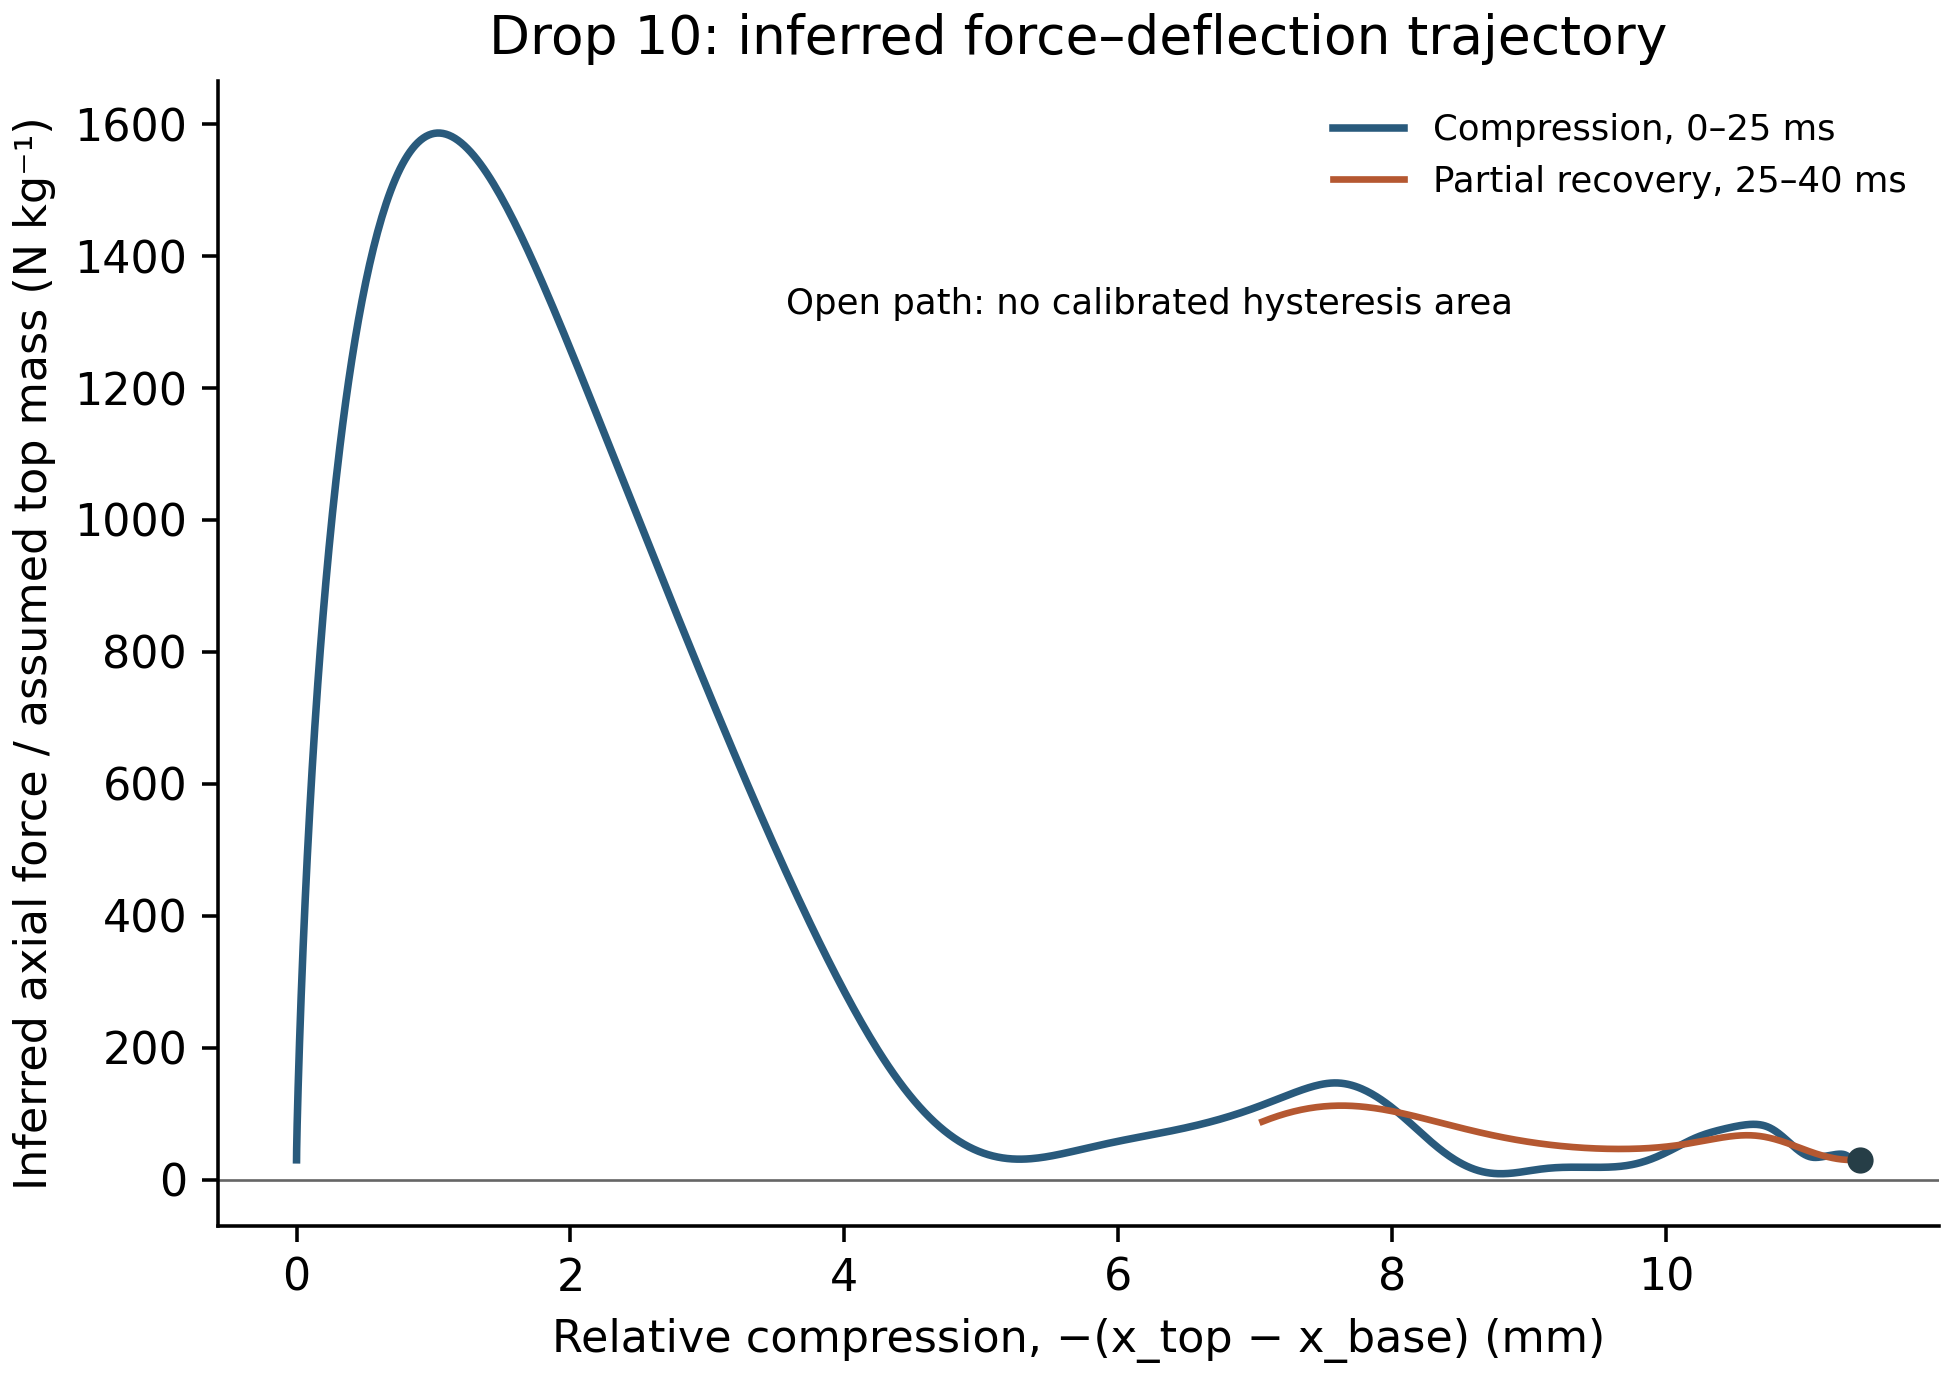

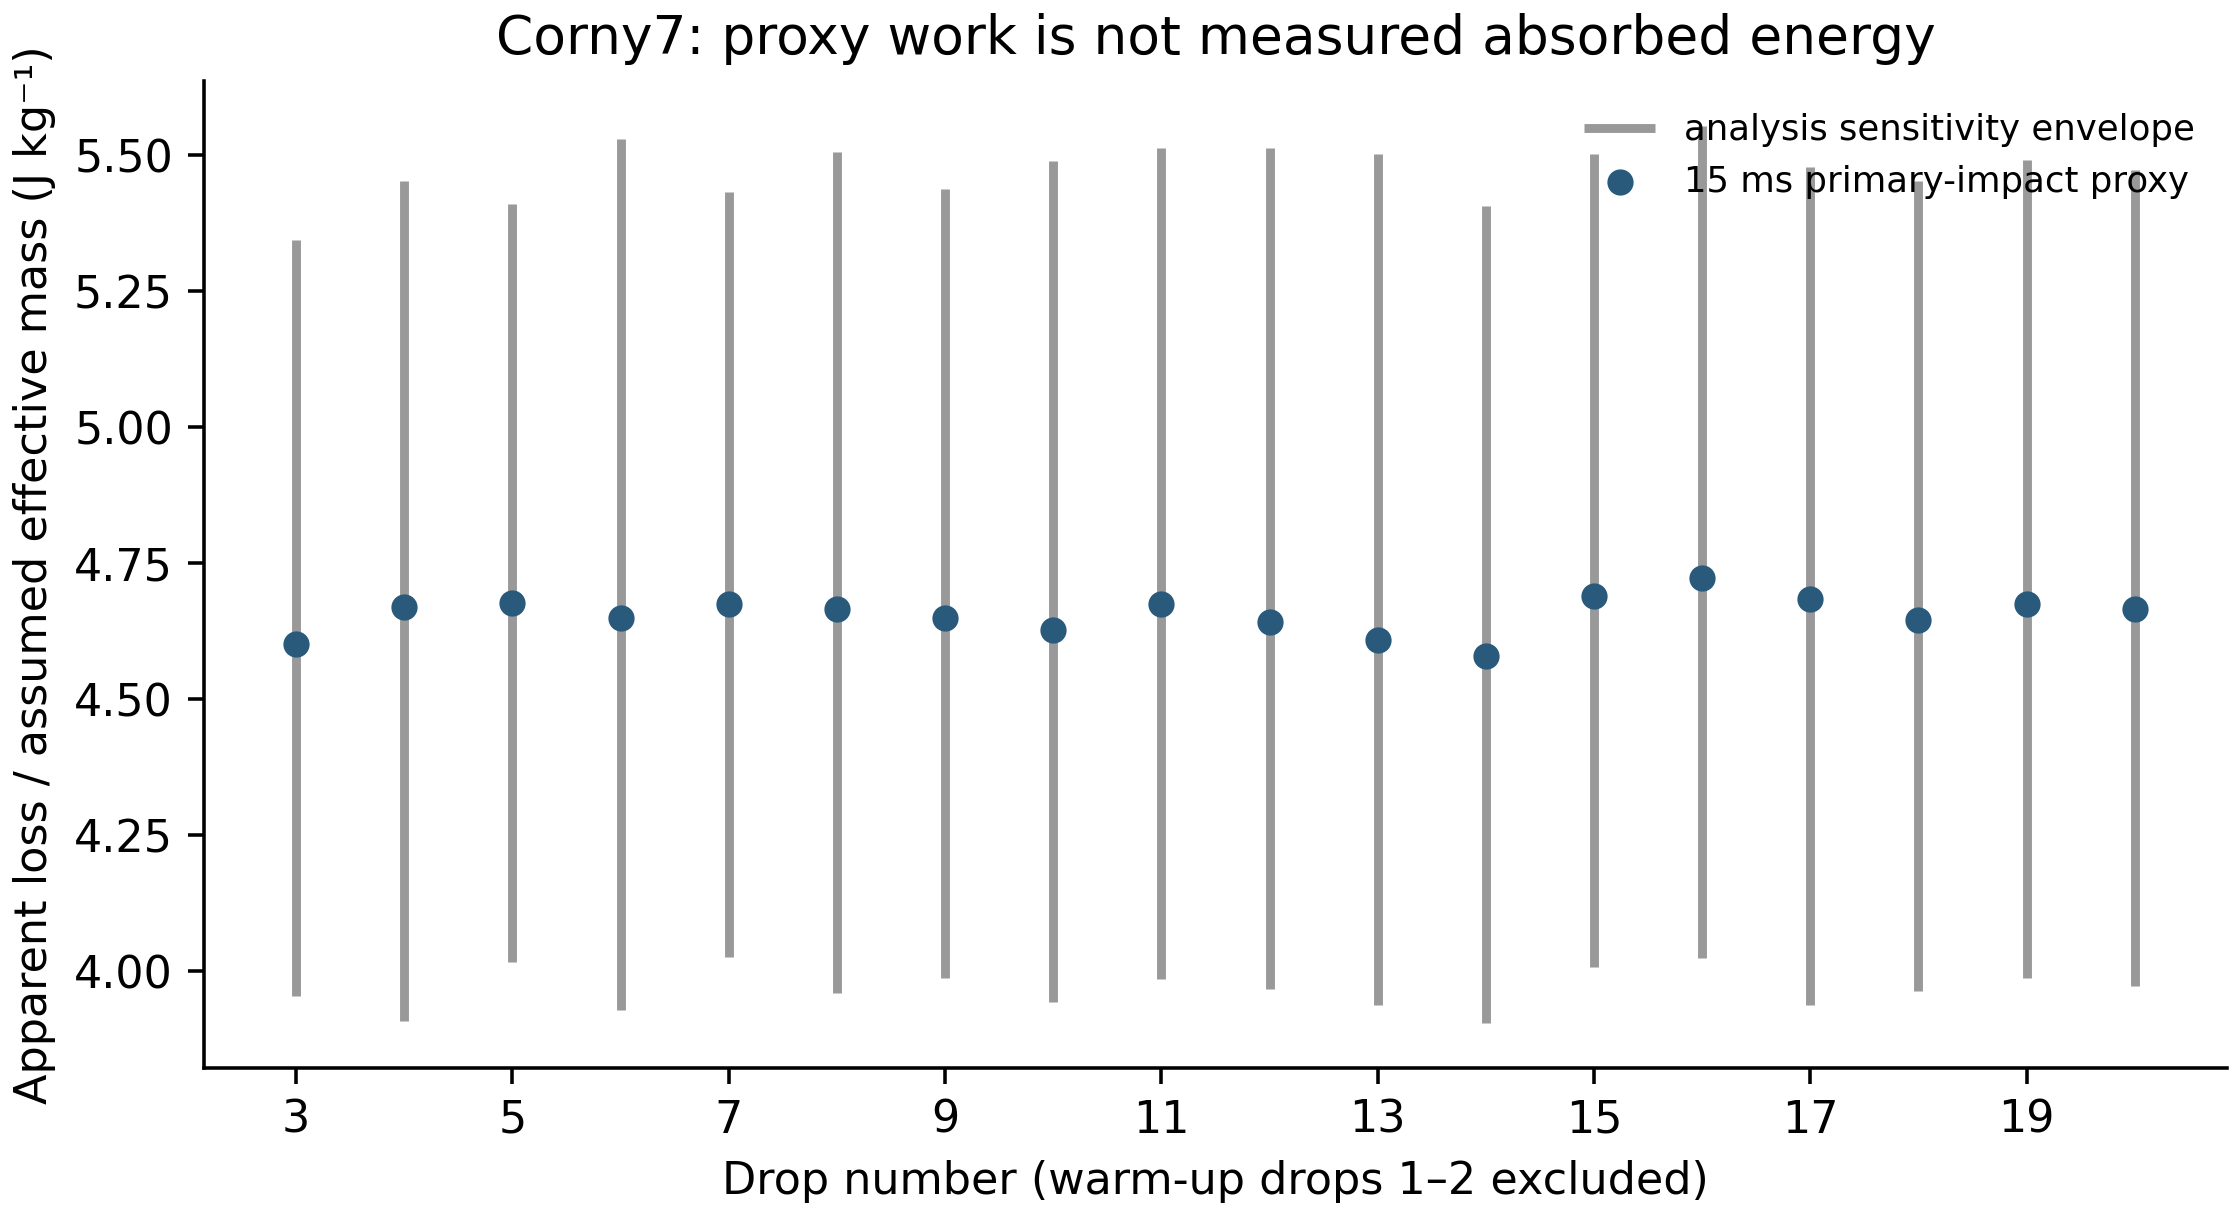

In [13]:
p=out/'work_proxy_analysis.py';s=p.read_text();old='''ax.plot(C,r['F'],color='#295a7c',lw=1.5,label='Drop 10, first impact / release')
for idx in [int(np.argmin(abs(r['t']-t))) for t in [.003,.009,.020,.030,.039]]:
    ax.scatter(C[idx],r['F'][idx],s=18,color='#b55831',zorder=3)
    ax.annotate(f'{r["t"][idx]*1000:.0f} ms',(C[idx],r['F'][idx]),xytext=(4,4),textcoords='offset points',fontsize=8)
''';new='''turn=int(np.argmin(abs(r['v'][:len(r['v'])-1][(r['t'][:len(r['v'])-1]>.008)]))) if False else np.argmin(r['L'])
ax.plot(C[:turn+1],r['F'][:turn+1],color='#295a7c',lw=1.7,label='Compression, 0–25 ms')
ax.plot(C[turn:],r['F'][turn:],color='#b55831',lw=1.5,label='Partial recovery, 25–40 ms')
ax.scatter([C[turn]],[r['F'][turn]],s=24,color='#263e47',zorder=3)
ax.legend(frameon=False,loc='upper right',fontsize=8)
''';assert old in s;s=s.replace(old,new).replace("turn=int(np.argmin(abs(r['v'][:len(r['v'])-1][(r['t'][:len(r['v'])-1]>.008)]))) if False else np.argmin(r['L'])","turn=np.argmin(r['L'])");s=s.replace("ax.text(.02,.98,'Open path, not a measured hysteresis loop',transform=ax.transAxes,va='top',fontsize=8,\n        bbox=dict(facecolor='white',alpha=.85,edgecolor='none'))","ax.text(.33,.82,'Open path: no calibrated hysteresis area',transform=ax.transAxes,va='top',fontsize=8,\n        bbox=dict(facecolor='white',alpha=.85,edgecolor='none'))")
p.write_text(s)
p=subprocess.run([sys.executable,str(out/'work_proxy_analysis.py')],capture_output=True,text=True,timeout=180);print(p.returncode,p.stderr[:1000]);
from IPython.display import display,Image
for f in ['drop10_force_deflection.png','drop_work_sensitivity.png']:
 display(Image(filename=str(out/f),width=710))

In [14]:
# Isolate code prior to data loading, execute precisely original routine with two selected drops.
import ast
mod=ast.parse(src);ns={'np':np,'sp':sp};exec(compile(ast.Module(body=[node for node in mod.body if isinstance(node,ast.FunctionDef)],type_ignores=[]),'original','exec'),ns)
for k in [1,2]:
 z=w[w.drop_number==k];t=z.time_ms.to_numpy()*1e-3;top=z.ch2_g.to_numpy()*9.81;bottom=z.ch5_g.to_numpy()*9.81
 Wt,Wtop,Wbottom=ns['numaric_work'](t,top,bottom);vr=integ.cumulative_trapezoid(top-bottom,t,initial=0);L=integ.cumulative_trapezoid(vr,t,initial=0)
 for en in [15,30,99.98]:
  idx=np.argmin(abs(t*1000-en)); print('drop',k,'ms',en,'W',Wt[idx],'Wtop',Wtop[idx],'Wbottom',Wbottom[idx], 'vrel',vr[idx],'L mm',L[idx]*1000)
 print('end kinetic upper bound',.5*d.loc[d.drop_number==k,'input_delta_v_m_s'].iloc[0]**2,'mg time-ch2 static-fall error?',np.median(top[-1500:])/9.81)
print('students force CH2 first impact min/max',[(k,float((w[w.drop_number==k].ch2_g.iloc[:750]+1).min()),float((w[w.drop_number==k].ch2_g.iloc[:750]+1).max())) for k in [1,2]])

drop 1 ms 15 W -3.6633353013042314 Wtop 0.04512257910631209 Wbottom -3.708457880410543 vrel -5.006368692000006 L mm -62.990476593030046
drop 1 ms 30 W -2.9513741782491074 Wtop 0.008668204791695952 Wbottom -2.9600423830407987 vrel -5.063597877600002 L mm -141.03963930412834
drop 1 ms 99.98 W -11.278084965922268 Wtop 2.0471453158760657 Wbottom -13.325230281798415 vrel -1.9624699970999981 L mm -341.3823846392612
end kinetic upper bound 15.1415045 mg time-ch2 static-fall error? 1.5554999999999999
drop 2 ms 15 W -3.147531389344255 Wtop 0.039371466784619905 Wbottom -3.1869028561288806 vrel -5.090993675999999 L mm -62.78379175135795
drop 2 ms 30 W -0.8761448546208699 Wtop 0.043095473084773 Wbottom -0.9192403277056481 vrel -5.506534975500002 L mm -145.56248984474078
drop 2 ms 99.98 W -9.459488563303363 Wtop 0.9165084697433757 Wbottom -10.37599703304677 vrel -3.619184759100003 L mm -416.25384224100367
end kinetic upper bound 13.791751999999999 mg time-ch2 static-fall error? 0.667
students force

In [15]:
# concise source details obtained from retrieved web-search entries
for j in [1,2,3]:
 print('\nQUERY',queries[j]);
 for z in results[j][:4]: print(z.get('title'),z.get('url'),(z.get('snippet') or '')[:650])
# demonstrate convergence student right-end vs midpoint/trapezoid on actual drop
for k in [1,10]:
 z=w[w.drop_number==k];t=z.time_ms.to_numpy()/1000;top=z.ch2_g.to_numpy()*9.81;bot=z.ch5_g.to_numpy()*9.81
 r=integ.cumulative_trapezoid(top-bot,t,initial=0);U=integ.cumulative_trapezoid(r,t,initial=0)
 right=np.sum((9.81+top[1:])*np.diff(U));tr=integ.trapezoid((9.81+top)*r,t)
 print('drop',k,'student left-top force right sample',right,'trapezoid Fv',tr,'delta',right-tr)



QUERY ASTM D1596 dynamic shock cushioning characteristics packaging materials drop test energy
D1596 Standard Test Method for  Dynamic Shock Cushioning Characteristics of Packaging Material https://store.astm.org/d1596-14r23.html D1596 Standard Test Method for Dynamic Shock Cushioning Characteristics of Packaging Material

# Standard Test Method for Dynamic Shock Cushioning Characteristics of Packaging Material

Standard Test Method for Dynamic Shock Cushioning Characteristics of Packaging Material D1596-14R23 ASTM|D1596-14R23|en-US Standard Test Method for Dynamic Shock Cushioning Characteristics of Packaging Material Standard D1596 Standard Test Method for Dynamic Shock Cushioning Characteristics of Packaging Material> new BOS Vol. 15.10 Committee D10

 $ 64.00 In stock 

 ASTM International 

Significance and Use

5.1 Dynamic cushioning test data obtained by this t
D1596 Standard Test Method for  Dynamic Shock Cushioning Characteristics of Packaging Material https://store.astm.org/

In [16]:
src2=pathlib.Path('justin_numarical_work.py').read_text();mod2=ast.parse(src2);ns2={'np':np,'sp':sp,'mpl':__import__('matplotlib.pyplot',fromlist=['plot'])};exec(compile(ast.Module(body=[node for node in mod2.body if isinstance(node,ast.FunctionDef)],type_ignores=[]),'numeric-original','exec'),ns2)
tv=np.arange(-.66543,2.49149,8e-6);ref=ns2['true_solution'](tv);est=ns2['numaric_work'](tv,ns2['test_fun']);u,v=3.913765976614389e-06,3.839256520011986e-05;adj=ns2['numaric_work'](tv,ns2['test_fun'],u=u,v=v)
print('poly n',len(tv),'start',tv[0],'ref first/last',ref[0],ref[-1], 'estimated first/last',est[0],est[-1], 'corrected first/last',adj[0],adj[-1]);print('u and v cumulative correction integrated',np.sum(u*ns2['test_fun'](tv[1:])+v),'original-ref-last',est[-1]-ref[-1],'corrected-ref-last',adj[-1]-ref[-1]);
# data summary compact
rdf=pd.read_csv(out/'drop_03_20_work_proxy.csv');print('T180 mean',rdf.T180.mean(),'proxy CV %',rdf.apparent_loss_J_per_kg_15ms.std()/rdf.apparent_loss_J_per_kg_15ms.mean()*100,'mean comp',rdf.compression_15ms_mm.mean());print('bound measured delta v minmax',(.5*rdf.input_delta_v_m_s**2).min(),(.5*rdf.input_delta_v_m_s**2).max());print('files',[(p.name,p.stat().st_size) for p in out.iterdir()])

poly n 394616 start -0.66543 ref first/last -0.002062368719976968 44.56410580047259 estimated first/last 0.0 38.593456187875056 corrected first/last 0.0 44.56616816919317
u and v cumulative correction integrated 5.972711981317508 original-ref-last -5.9706496125975335 corrected-ref-last 0.0020623687205798547
T180 mean 0.8031055555555556 proxy CV % 0.7457253368601293 mean comp 10.376215694444445
bound measured delta v minmax 13.343778000000002 13.912812500000001
files [('drop_work_sensitivity.pdf', 17072), ('drop10_force_deflection.pdf', 19612), ('drop10_force_deflection.png', 195262), ('drop_03_20_work_proxy.csv', 2715), ('drop_work_sensitivity.png', 139277), ('drop10_velocity_displacement.png', 198622), ('work_proxy_analysis.py', 5865), ('drop10_velocity_displacement.pdf', 20289)]


In [17]:
# Direction/impulse check: subtract tail, CFC180 filter then integrate first 0..15 ms.
for k in [1,2,3,10,20]:
 z=w[w.drop_number==k];t=z.time_ms.to_numpy()/1000; sl=t<=.015
 print('drop',k,end=' ')
 for c in ['ch2_g','ch3_g','ch4_g','ch5_g']:
  x=z[c].to_numpy();x=sig.sosfiltfilt(sos,(x-np.median(x[t>=.070]))*G)
  print(c,'peak± G',round(x[sl].max()/G,1),round(x[sl].min()/G,1),'dv',round(integ.trapezoid(x[sl],t[sl]),2),end='; ')
 print()

drop 1 ch2_g peak± G 26.5 -27.3 dv 0.03; ch3_g peak± G 24.4 -71.1 dv -0.68; ch4_g peak± G 163.1 -1.3 dv 4.69; ch5_g peak± G 222.8 -1.1 dv 5.64; 
drop 2 ch2_g peak± G 25.5 -21.7 dv 0.09; ch3_g peak± G 21.5 -71.2 dv -0.67; ch4_g peak± G 161.5 -1.3 dv 4.96; ch5_g peak± G 220.6 -2.7 dv 5.44; 
drop 3 ch2_g peak± G 25.2 -19.2 dv 0.12; ch3_g peak± G 21.0 -72.7 dv -0.67; ch4_g peak± G 161.0 -1.7 dv 4.89; ch5_g peak± G 219.2 -3.0 dv 5.34; 
drop 10 ch2_g peak± G 26.3 -18.3 dv 0.12; ch3_g peak± G 20.1 -74.7 dv -0.77; ch4_g peak± G 160.8 -0.1 dv 4.99; ch5_g peak± G 219.8 -2.8 dv 5.36; 
drop 20 ch2_g peak± G 28.4 -18.5 dv 0.21; ch3_g peak± G 21.2 -75.8 dv -0.75; ch4_g peak± G 160.6 -0.0 dv 4.96; ch5_g peak± G 220.2 -2.9 dv 5.38; 
